---
title: "Chapter 7: Linear Models"
---

::: {.callout-lo}

By the end of this chapter, you will be able to:

- Explain how linear models make predictions using coefficients and an intercept.
- Explain intuitively how a loss function evaluates predictions and guides model fitting.
- Describe the behaviour of squared-error loss and log loss, including which mistakes they penalize most strongly.
- Distinguish the loss used to fit a model from the score used to evaluate it.
- Fit and use `Ridge` for regression and `LogisticRegression` for classification.
- Explain at a high level why linear models use regularization and how `alpha` and `C` affect model complexity.
- Explain how logistic regression converts a linear score into a probability and a class prediction.
- Interpret linear-model coefficients while accounting for scaling, correlated features, and the distinction between prediction and causation.
- Contrast parametric linear models with a non-parametric model such as $k$-NN.
- Describe important strengths and limitations of linear models.
:::

Linear models summarize the relationship between the features and target using one coefficient per feature and an intercept. Prediction then requires only a weighted sum.

This compact prediction rule makes linear models fast and often relatively easy to inspect. It also restricts the relationships they can represent. In this chapter, we will develop the common machinery behind linear regression and logistic regression, examine how these models learn their coefficients, and consider when a linear relationship is (and is not) a useful approximation.

**Imports**

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import log_loss
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

DATA_DIR = Path("data")

## What makes a model linear?

Suppose we want to predict a student's exam grade from the number of hours they studied. A linear model represents its prediction as a line:

$$
\hat{y} = w_1x_1 + b.
$$

Here, $x_1$ is the number of study hours, $w_1$ is the **coefficient** (or weight), and $b$ is the **intercept** (or bias). The coefficient tells us how much the prediction changes when the feature increases by one unit (one hour in this example).

The intercept is the model’s prediction when the feature equals zero. For example, suppose a hypothetical grading rule awards every student 5 points regardless of study time, then adds points based on the number of hours studied. The intercept would be 5: it provides the baseline prediction when study time is zero. Whether the intercept has a meaningful interpretation depends on the problem. From a modelling perspective, the intercept gives the fitted model flexibility to shift its predictions up or down.

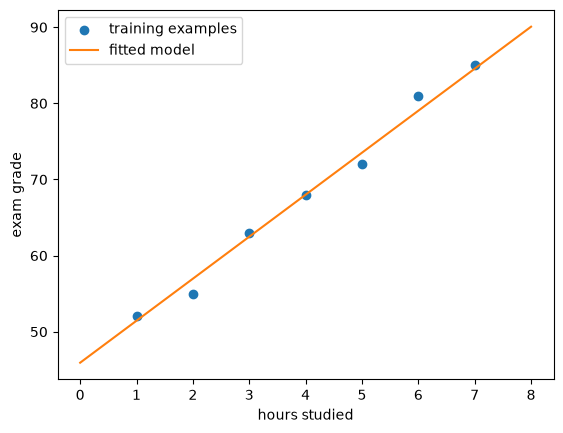

In [2]:
study_data = pd.DataFrame(
    {
        "hours": [1, 2, 3, 4, 5, 6, 7],
        "grade": [52, 55, 63, 68, 72, 81, 85],
    }
)

study_model = Ridge(alpha=1.0)  # a commonly used linear model for regression problems
study_model.fit(study_data[["hours"]], study_data["grade"])

hours_grid = pd.DataFrame({"hours": np.linspace(0, 8, 100)})
plt.scatter(study_data["hours"], study_data["grade"], label="training examples")
plt.plot(
    hours_grid["hours"],
    study_model.predict(hours_grid),
    color="tab:orange",
    label="fitted model",
)
plt.xlabel("hours studied")
plt.ylabel("exam grade")
plt.legend();

According to the fitted line, the predicted grade for a student who studies for about 5.5 hours is approximately 76%. This is a prediction from the model, not a guarantee about what the student will receive.

In [3]:
pd.Series(
    {
        "coefficient": study_model.coef_[0],
        "intercept": study_model.intercept_,
        "prediction_for_5.5_hours": study_model.predict(
            pd.DataFrame({"hours": [5.5]})
        )[0],
    }
)

coefficient                     5.517241
intercept                      45.931034
prediction_for_5.5_hours       76.275862
dtype: float64

The model makes a strong simplifying assumption: the predicted grade changes at a constant rate as study time increases. Because the learned coefficient is positive, it predicts that more study time always produces a higher grade. Is that plausible for every student and any number of hours?

In reality, additional study may have diminishing benefits, excessive studying may cause fatigue, and grades depend on many factors absent from this one-feature model. The fitted line would eventually predict grades above 100% if we extrapolated far enough. Moreover, an association between study time and grades does not by itself show that additional studying causes the predicted increase.

A linear model can still be useful when a straight line is a reasonable approximation over the range where predictions will be made. The line does not need to pass through every training example. Fitting must choose a coefficient and intercept from many possible values; shortly, we will look under the hood of `fit` and introduce the criterion used to make that choice.

With more features, each feature makes its own contribution. Suppose a model uses hours studied and practice sets completed. For one student,

| Feature | Value | Coefficient | Contribution |
|---|---:|---:|---:|
| Hours studied ($x_1$) | 5 | 4 | 20 |
| Practice sets ($x_2$) | 6 | 2 | 12 |
| Intercept ($b$) | | | 45 |

so the predicted grade is $20+12+45=77$. We can collect the feature values and coefficients into vectors:

$$
\mathbf{x}=
\begin{bmatrix}5\\6\end{bmatrix},
\qquad
\mathbf{w}=
\begin{bmatrix}4\\2\end{bmatrix}.
$$

The dot product $\mathbf{w}^{\mathsf T}\mathbf{x}$ multiplies corresponding entries and adds them. Therefore,

$$
\hat{y}
=\mathbf{w}^{\mathsf T}\mathbf{x}+b
=
\begin{bmatrix}4&2\end{bmatrix}
\begin{bmatrix}5\\6\end{bmatrix}
+45
=77.
$$

In general, this is shorthand for

$$
\hat{y}=w_1x_1+w_2x_2+\cdots+w_dx_d+b.
$$

For a complete dataset, we stack the examples as rows of a feature matrix $X$:

$$
X=
\begin{bmatrix}
5&6\\
2&3\\
7&5
\end{bmatrix},
\qquad
\mathbf{y}=
\begin{bmatrix}75\\62\\86\end{bmatrix}.
$$

Each column of $X$ is a feature, while $\mathbf{y}$ contains the observed targets. The model applies the same coefficient vector to every row:

$$
\hat{\mathbf{y}}=X\mathbf{w}+b,
$$

where $+b$ means adding the intercept to every prediction. You may also see the prediction written more compactly as

$$
\hat{\mathbf{y}}=X\mathbf{w},
$$

without a separate $b$. In that convention, $X$ contains an additional feature whose value is always 1, and the corresponding coefficient in $\mathbf{w}$ is the intercept. Because $1\times b=b$, this adds the intercept to every prediction. We say that the intercept has been **absorbed** into $X\mathbf{w}$.

The next section explains how fitting compares $\hat{\mathbf{y}}$ with $\mathbf{y}$ to choose the coefficients and intercept.

With one feature, this prediction rule describes a line; with two features, a plane; and with more features, a **hyperplane**.

## What happens during `fit`?

So far, we have mostly treated a scikit-learn model as an object with a convenient interface: call `fit` using training data, then use the fitted model to predict and evaluate new examples. Let us briefly look inside `fit`.

During supervised learning, a model uses the feature matrix $X$ and its current parameters to produce predictions $\hat{y}$. A **loss function** compares those predictions with the observed targets $y$ and returns a number describing how poorly they agree. Low loss means the predictions are close to what the loss function rewards; high loss means they are not.

An **optimization** procedure searches for parameter values that reduce this loss. It repeatedly evaluates predictions, measures their loss, and updates the parameters. Scikit-learn performs this work when we call `fit`. The computational details of optimization are beyond the scope of this book; the important idea is that the loss function tells the fitting procedure what counts as a better model.

![The supervised-learning training loop. A model uses features X and its current parameters to produce predictions. A loss function compares the predictions with observed targets y, and an optimization procedure updates the parameters to reduce the loss.](img/supervised-learning-training.png){fig-alt="The supervised-learning training loop. Features X enter a model, which produces predictions y hat. A loss function compares the predictions with observed targets y. Optimization updates the model parameters and repeats the cycle." fig-cap="During training, loss provides feedback that guides updates to the model parameters. This diagram uses squared error as an example; the loss depends on the model." width="95%"}

The choice of loss function depends on the prediction problem and on which kinds of mistakes we want the model to treat as costly. Different loss functions can therefore lead to different fitted models.

The diagram shows a common choice for regression: **mean squared error**. For each training example, $Xw-\mathbf{y}$ subtracts the observed target from the model's prediction. The result contains one prediction error for each example. These differences are called **residuals**. Mean squared error squares the residuals and takes their mean. A large mean squared error indicates that the predictions have large squared differences from the targets, on average. A small value indicates that the predictions are closer to the targets according to this particular loss. **Ordinary least squares** fits a linear model by finding coefficients that minimize squared-error loss.

A low training loss means that the model fits its training examples well; it does not necessarily mean that the model will predict new examples well. We still need validation or cross-validation to assess generalization. Loss is also not necessarily the value reported by a model's `score` method: a model can be fitted using one objective and evaluated using another measure. We will see this distinction with `Ridge` regression.

## Linear regression with `Ridge`

**Linear regression** uses a linear prediction rule for a numeric target. In this book, we will use scikit-learn's `Ridge` estimator rather than `LinearRegression`. Both use coefficients and an intercept to make predictions, but `Ridge` includes **regularization**, which discourages unnecessarily large coefficients. This often makes the fitted model more stable when features contain overlapping information and can reduce overfitting.

Let's try `Ridge` on a housing-price prediction problem using the California housing dataset. Each row represents a census block group rather than an individual house, and the target is the median house value in that block group.

In [4]:
housing = pd.read_csv(DATA_DIR / "california_housing.csv")
housing = housing.drop(columns="ocean_proximity").dropna()

X_housing = housing.drop(columns="median_house_value")
y_housing = housing["median_house_value"]
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=123
)

X_train_h.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
2851,-118.95,35.38,35.0,2220.0,388.0,906.0,373.0,3.5938
16353,-121.32,38.04,30.0,249.0,44.0,167.0,45.0,4.5000
13403,-117.47,34.12,6.0,10565.0,1767.0,5690.0,1555.0,4.1797
1781,-122.36,37.94,45.0,907.0,188.0,479.0,161.0,3.0862
2005,-119.80,36.74,25.0,1717.0,542.0,1343.0,471.0,0.7990


We begin with a mean-prediction baseline. We then place `StandardScaler` and `Ridge` in a pipeline so that the scaler is fit separately within each cross-validation fold.

In [5]:
regression_models = {
    "mean baseline": DummyRegressor(),
    "scaled Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
}

regression_results = {}
for name, model in regression_models.items():
    scores = cross_validate(model, X_train_h, y_train_h, return_train_score=True)
    regression_results[name] = {
        "mean_train_score": scores["train_score"].mean(),
        "mean_cv_score": scores["test_score"].mean(),
    }

pd.DataFrame(regression_results).T

,mean_train_score,mean_cv_score
mean baseline,0.000000,-0.000121
scaled Ridge,0.636345,0.634073


By default, regression estimators use $R^2$ for their `score` method, so these values are not losses. The `Ridge` model improves substantially over always predicting the training mean. Later chapters examine regression metrics and their interpretation in more detail.

### Controlling model complexity

Many sets of coefficients can fit the training data similarly, especially when features are correlated. In those situations, small changes to the training data can produce large changes in the learned coefficients. Regularization makes `Ridge` prefer less extreme coefficients unless larger values improve the fit enough to justify them. At a high level, this is another way to control model complexity.

::: {.callout-note collapse="true" title="Optional: What `Ridge` minimizes"}
Ordinary least squares chooses coefficients by minimizing squared-error loss. `Ridge` adds a penalty based on the squared coefficients:

$$
\text{quantity minimized by Ridge}
=
\text{squared-error loss}
+
\alpha\sum_{j=1}^{d}w_j^2.
$$

The first term rewards predictions close to the training targets. The second discourages large coefficients. The optimization procedure searches for coefficients that balance these two goals. The details of that optimization are beyond the scope of this book.
:::

The hyperparameter `alpha` controls the strength of regularization:

- A larger `alpha` discourages large coefficients more strongly, usually producing a less flexible model with a greater risk of underfitting.
- A smaller `alpha` allows the model to follow the training data more closely, usually producing a more flexible model with a greater risk of overfitting.

We will use `Ridge` rather than setting `alpha` to zero or switching to `LinearRegression`. The appropriate positive value of `alpha` is data-dependent and can be selected using cross-validation.

Scaling matters because regularization acts on coefficient magnitudes. Without scaling, changing a feature from dollars to thousands of dollars changes the size of its coefficient and therefore how strongly that feature is affected by the penalty. This is why our `Ridge` pipeline includes `StandardScaler`.

In [8]:
alpha_results = []
for alpha in 10.0 ** np.arange(-3, 7):
    ridge_pipe = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
    scores = cross_validate(
        ridge_pipe, X_train_h, y_train_h, return_train_score=True
    )
    alpha_results.append(
        {
            "alpha": alpha,
            "mean_train_score": scores["train_score"].mean(),
            "mean_cv_score": scores["test_score"].mean(),
        }
    )

pd.DataFrame(alpha_results)

,alpha,mean_train_score,mean_cv_score
0,0.001,0.636345,0.634070
1,0.010,0.636345,0.634070
2,0.100,0.636345,0.634071
3,1.000,0.636345,0.634073
4,10.000,0.636332,0.634085
5,100.000,0.635347,0.633318
6,1000.000,0.606943,0.605844
7,10000.000,0.443226,0.442782
8,100000.000,0.115529,0.115328
9,1000000.000,0.013651,0.013520


The effect of regularization is gradual, and the best value is data-dependent. We should not choose `alpha` by repeatedly checking the test set. Chapter 8 develops methods for selecting hyperparameters using only the training data.

## Interpreting linear-model coefficients

After fitting the pipeline, we can inspect the `Ridge` coefficients. Because the pipeline standardizes the features first, each coefficient describes the change in the prediction associated with a one-standard-deviation increase in that feature, **holding the other represented features fixed**.

In [9]:
ridge_pipe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
ridge_pipe.fit(X_train_h, y_train_h)

ridge_coefficients = pd.Series(
    ridge_pipe.named_steps["ridge"].coef_,
    index=X_train_h.columns,
    name="coefficient",
).sort_values()
ridge_coefficients.to_frame()

,coefficient
latitude,-90755.504776
longitude,-85470.620474
population,-42283.519254
total_rooms,-19969.273269
housing_median_age,14668.590996
households,19226.321907
total_bedrooms,47525.803163
median_income,77102.618751


A positive coefficient means that increasing the feature, while keeping the other represented features fixed, increases the model's prediction. A negative coefficient decreases the prediction. After comparable scaling, a larger absolute coefficient generally means that a one-standard-deviation change contributes more to this model's prediction.

That interpretation needs several qualifications:

- The coefficient describes the fitted model, not necessarily how the world works. It is not a causal effect.
- Correlated features can share or exchange predictive information, making individual coefficients unstable or surprising.
- Without comparable scaling, coefficient magnitudes cannot be compared directly because a one-unit change means something different for each feature.
- A coefficient gives a constant change per unit. If the real relationship curves or depends on another feature, that summary may be inadequate.
- The intercept may not have a useful real-world interpretation if an all-zero feature vector is impossible or far outside the observed data.

Coefficients can help us understand how a model computes predictions, but they should be treated as evidence about the model rather than automatic feature importance or causal evidence.

::: {.callout-reflection}
Suppose median income and average number of rooms are strongly correlated. If the coefficient of average rooms is negative, does that establish that adding a room would lower a district's house values? What alternative explanations could produce that coefficient?
:::

## Logistic regression

Regression produces a numeric prediction directly. For classification, we instead need to choose among classes. Despite its name, **logistic regression** is a classifier. Like linear regression, it first computes a weighted sum:

$$
z = \mathbf{w}^{\mathsf T}\mathbf{x}+b.
$$

This value is often called the **decision score** or raw score. In binary classification, its sign determines which side of the decision boundary an example lies on.

We will predict whether a city is in Canada or the United States using longitude and latitude. Geography is not truly separated by one straight line—Alaska is an obvious complication—which makes this example useful for studying both the model and its limitations.

In [10]:
cities = pd.read_csv(DATA_DIR / "canada_usa_cities.csv")
X_cities = cities[["longitude", "latitude"]]
y_cities = cities["country"]
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cities, y_cities, test_size=0.2, random_state=123, stratify=y_cities
)

classification_models = {
    "most-frequent baseline": DummyClassifier(strategy="most_frequent"),
    "scaled logistic regression": make_pipeline(
        StandardScaler(), LogisticRegression(random_state=123)
    ),
}

classification_results = {}
for name, model in classification_models.items():
    scores = cross_validate(model, X_train_c, y_train_c, return_train_score=True)
    classification_results[name] = {
        "mean_train_accuracy": scores["train_score"].mean(),
        "mean_cv_accuracy": scores["test_score"].mean(),
    }

pd.DataFrame(classification_results).T

,mean_train_accuracy,mean_cv_accuracy
most-frequent baseline,0.610773,0.610695
scaled logistic regression,0.808394,0.808556


### Scores and the decision boundary

We fit the pipeline to examine a prediction. The model's `classes_` attribute records the class order. In binary logistic regression, a negative decision score selects `classes_[0]`, while a positive score selects `classes_[1]`. This ordering is deterministic; the model does not randomly designate the positive class.

In [11]:
logistic_pipe = make_pipeline(
    StandardScaler(), LogisticRegression(random_state=123)
)
logistic_pipe.fit(X_train_c, y_train_c)

example = X_test_c.iloc[[0]]
pd.DataFrame(
    {
        "decision_score": logistic_pipe.decision_function(example),
        "prediction": logistic_pipe.predict(example),
    }
)

,decision_score,prediction
0,-0.39582,Canada


In [12]:
logistic_pipe.named_steps["logisticregression"].classes_

array(['Canada', 'USA'], dtype=object)

The **decision boundary** contains feature values whose score is zero:

$$
\mathbf{w}^{\mathsf T}\mathbf{x}+b=0.
$$

With two features, this boundary is a line. With three, it is a plane; with $d$ features, it is a $(d-1)$-dimensional hyperplane. A linear classifier can still make mistakes on its training data: a linear boundary is the form of the rule, not a requirement that the classes be perfectly separable.

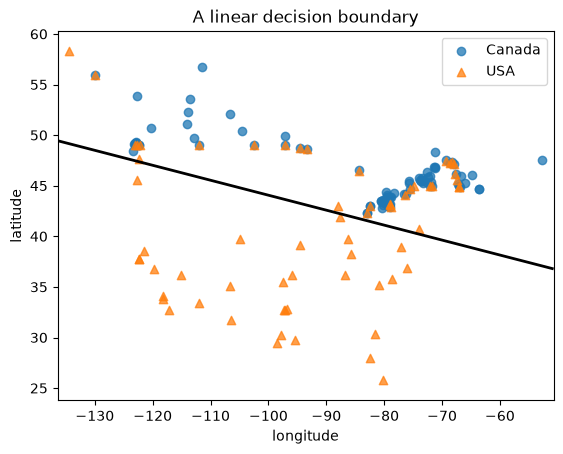

In [13]:
x_min, x_max = X_train_c["longitude"].min() - 2, X_train_c["longitude"].max() + 2
y_min, y_max = X_train_c["latitude"].min() - 2, X_train_c["latitude"].max() + 2
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300),
)
grid = pd.DataFrame({"longitude": xx.ravel(), "latitude": yy.ravel()})
grid_scores = logistic_pipe.decision_function(grid).reshape(xx.shape)

for country, marker in zip(logistic_pipe.classes_, ["o", "^"]):
    mask = y_train_c == country
    plt.scatter(
        X_train_c.loc[mask, "longitude"],
        X_train_c.loc[mask, "latitude"],
        label=country,
        marker=marker,
        alpha=0.75,
    )
plt.contour(xx, yy, grid_scores, levels=[0], colors="black", linewidths=2)
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.legend()
plt.title("A linear decision boundary");

### From scores to probabilities

The sign of the score is enough to choose a class, but its magnitude contains additional information. Logistic regression passes the score through the **sigmoid function**:

$$
\sigma(z)=\frac{1}{1+e^{-z}}.
$$

The sigmoid maps any real-valued score to a number between 0 and 1. This number is the model's estimated probability of `classes_[1]`. A score of zero maps to 0.5, so thresholding the probability at 0.5 is equivalent to thresholding the score at zero.

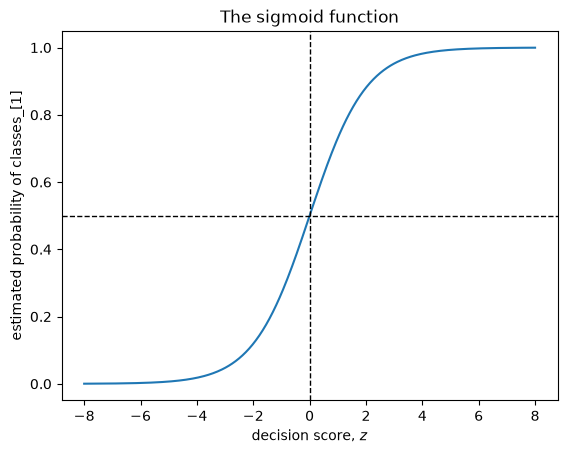

In [14]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


scores = np.linspace(-8, 8, 400)
plt.plot(scores, sigmoid(scores))
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.axhline(0.5, color="black", linestyle="--", linewidth=1)
plt.xlabel("decision score, $z$")
plt.ylabel("estimated probability of classes_[1]")
plt.title("The sigmoid function");

In [15]:
decision_score = logistic_pipe.decision_function(example)[0]
pd.Series(
    {
        "sigmoid(decision_score)": sigmoid(decision_score),
        "predict_proba for classes_[1]": logistic_pipe.predict_proba(example)[0, 1],
    }
)

sigmoid(decision_score)          0.402317
predict_proba for classes_[1]    0.402317
dtype: float64

`predict_proba` returns one column per class in the order given by `classes_`. For binary classification the two probabilities sum to one. The larger probability determines the default hard prediction, but an application may choose a different threshold when different errors have different consequences.

An estimated probability is useful, but it should not automatically be treated as trustworthy confidence. A model can assign a high probability to an incorrect prediction, particularly when its assumptions are inadequate or deployment examples differ from its training data. Later chapters discuss evaluation measures and probability calibration.

### Log loss

Logistic regression chooses its coefficients using **log loss**, also called binary cross-entropy loss. If $p_i$ is the predicted probability of the positive class and $y_i$ is encoded as 0 or 1, the average log loss is

$$
-\frac{1}{n}\sum_{i=1}^{n}
\left[y_i\log(p_i)+(1-y_i)\log(1-p_i)\right].
$$

The formula is less important here than its behaviour. The loss is small when the model assigns high probability to the observed class. It grows when the model assigns the observed class a low probability, and a confident incorrect prediction receives a particularly large penalty.

In [16]:
probability_examples = pd.DataFrame(
    {
        "observed_class": [1, 1, 1, 0],
        "probability_of_class_1": [0.90, 0.60, 0.10, 0.90],
    },
    index=["confident correct", "less confident correct", "confident incorrect", "confident incorrect (class 0)"],
)
probability_examples["log_loss"] = [
    log_loss([observed], [[1 - probability, probability]], labels=[0, 1])
    for observed, probability in zip(
        probability_examples["observed_class"],
        probability_examples["probability_of_class_1"],
    )
]
probability_examples

,observed_class,probability_of_class_1,log_loss
confident correct,1,0.9,0.105361
less confident correct,1,0.6,0.510826
confident incorrect,1,0.1,2.302585
confident incorrect (class 0),0,0.9,2.302585


Accuracy would treat probabilities 0.51 and 0.99 identically when class 1 is observed: both produce the correct class. Log loss distinguishes them because fitting logistic regression is concerned with the probability assigned to the observed class, not only which side of 0.5 wins.

As with `Ridge`, the fitting objective also contains a regularization penalty. In scikit-learn's `LogisticRegression`, `C` controls regularization in the opposite direction from `Ridge`'s `alpha`:

- Smaller `C` means stronger regularization and usually a less flexible model.
- Larger `C` means weaker regularization and usually a more flexible model.

This reversal is easy to forget: `Ridge` exposes regularization *strength* through `alpha`, whereas logistic regression exposes an *inverse* regularization strength through `C`.

In [17]:
C_results = []
for C in 10.0 ** np.arange(-4, 5):
    model = make_pipeline(
        StandardScaler(), LogisticRegression(C=C, random_state=123)
    )
    scores = cross_validate(model, X_train_c, y_train_c, return_train_score=True)
    C_results.append(
        {
            "C": C,
            "mean_train_accuracy": scores["train_score"].mean(),
            "mean_cv_accuracy": scores["test_score"].mean(),
        }
    )

pd.DataFrame(C_results)

,C,mean_train_accuracy,mean_cv_accuracy
0,0.0001,0.610773,0.610695
1,0.0010,0.610773,0.610695
2,0.0100,0.714084,0.718895
3,0.1000,0.799405,0.802496
4,1.0000,0.808394,0.808556
5,10.0000,0.812872,0.808556
6,100.0000,0.814375,0.808556
7,1000.0000,0.814375,0.808556
8,10000.0000,0.814375,0.808556


## Confidence and model limitations

For a linear classifier, examples close to the decision boundary have scores near zero and probabilities near 0.5. Examples far from the boundary generally receive more extreme probabilities. Distance from the boundary describes the model's certainty under its fitted rule; it does not guarantee that the rule is correct.

In [18]:
train_predictions = X_train_c.copy()
train_predictions["observed"] = y_train_c
train_predictions["predicted"] = logistic_pipe.predict(X_train_c)
train_predictions["decision_score"] = logistic_pipe.decision_function(X_train_c)
train_predictions["predicted_probability"] = logistic_pipe.predict_proba(X_train_c).max(axis=1)

train_predictions.sort_values("predicted_probability").head(5)

,longitude,latitude,observed,predicted,decision_score,predicted_probability
48,-122.3301,47.6038,USA,Canada,-0.058617,0.514650
33,-87.6244,41.8756,USA,USA,0.088508,0.522113
31,-74.0060,40.7127,USA,Canada,-0.121136,0.530247
61,-87.9225,43.0350,USA,Canada,-0.186385,0.546462
130,-83.0353,42.3171,Canada,Canada,-0.187538,0.546747


In [19]:
train_predictions.loc[
    train_predictions["observed"] != train_predictions["predicted"]
].sort_values("predicted_probability", ascending=False).head(5)

,longitude,latitude,observed,predicted,decision_score,predicted_probability
1,-134.4197,58.3019,USA,Canada,-2.254809,0.905065
24,-68.3219,47.3556,USA,Canada,-1.965534,0.877131
22,-69.2275,47.4562,USA,Canada,-1.957328,0.876243
23,-68.5897,47.2587,USA,Canada,-1.931892,0.873459
25,-67.9353,47.1575,USA,Canada,-1.930796,0.873338


The second table deliberately searches for confident mistakes rather than relying on hard-coded row numbers. Some cities in Alaska can be geographically far from the model's straight boundary even though they belong to the United States. The model can therefore be confidently wrong because its linear representation cannot express the actual geography.

This is a general lesson: probability estimates are conditional on the model, its features, and the data used to fit it. A high value from `predict_proba` is not a guarantee.

## Other linear classifiers

A support vector machine can also use a linear decision boundary. Logistic regression and a linear SVM both compute a weighted sum and can expose coefficients and an intercept, but they learn them using different loss functions. Logistic regression uses log loss and naturally provides probabilities. A linear SVM uses hinge loss and emphasizes whether examples lie on the correct side of a margin.

In scikit-learn, `LinearSVC` is designed specifically for linear classification, while `SVC(kernel="linear")` provides a linear-kernel version of the kernel SVM introduced in Chapter 4. The models may produce similar-looking boundaries, but their coefficients need not be identical because their fitting objectives differ. Logistic regression will be our main linear classifier when probability estimates are useful.

Now that we have seen what linear models learn and how they make predictions, we can compare their fitted representation with the $k$-NN approach from Chapter 4.


## Parametric and non-parametric models

Linear models are commonly described as **parametric**. Once the feature representation has been fixed, a linear model has a fixed-size prediction rule. A model with 100 features learns 100 coefficients and an intercept whether the training set contains 1,000 examples or one million.

$k$-NN is commonly described as **non-parametric**. It does not compress the training data into a fixed collection of coefficients. Fitting mainly stores the training examples, and prediction searches those examples for nearby points. As the training set grows, the stored model and the work required for a straightforward neighbour search also grow.

“Non-parametric” does not mean that a method has no settings: $k$, the distance measure, and neighbour weighting are hyperparameters. Similarly, “parametric” does not necessarily mean small or unable to overfit. A linear model applied to 100,000 features learns 100,001 parameters, and it may still overfit without enough data or regularization.

| Question | Linear model | $k$-NN |
|---|---|---|
| What does fitting retain? | Coefficients and an intercept | The training examples |
| Where is most computation? | During fitting | During prediction |
| What shapes can it represent directly? | A linear function or boundary | Flexible, locally determined shapes |
| What happens as training rows are added? | The number of coefficients stays fixed for fixed $d$ | Storage and straightforward prediction work grow |
| What assumption does it make? | A linear relationship is a useful approximation | Nearby examples tend to have similar targets |

These are tendencies, not guarantees about which model will perform better. A linear model can be a strong choice when the linear approximation is appropriate, when the feature matrix is large and sparse, or when fast prediction matters. $k$-NN can capture local structure that a linear model misses, but distance becomes difficult to use effectively in some high-dimensional representations.

## Strengths and limitations of linear models

Linear models are often strong baselines. They are typically fast to predict with, scale to many examples and features, and work well with sparse representations such as bag-of-words. Their coefficients make the calculation behind a prediction relatively transparent. Regularization provides a direct way to control model complexity.

Their central restriction is also clear: the prediction is linear in the represented features. Logistic regression separates classes with a hyperplane, and linear regression assigns the same coefficient to a feature throughout the feature space. Curved relationships, local patterns, and interactions may therefore be missed unless useful transformed or interaction features are supplied.

This limitation does not mean the raw data must literally follow a straight line. A linear model is linear in its **features**. Later feature-engineering techniques can create features that let a linear model represent some nonlinear relationships, although every transformation introduces new assumptions and potential complexity.

## Exercises

### Exercise 7.1: Count what the models retain

A dataset has 100 input features. Compare fitting a logistic-regression model on (a) 1,000 examples and (b) one million examples. How many coefficients and intercepts are learned in each case for binary classification? How would the stored fitted object differ conceptually if we instead used $k$-NN? Explain why “non-parametric” does not mean “has no hyperparameters.”

### Exercise 7.2: Trace a regression prediction and its loss

A linear model uses $\hat y=3x+10$. Compute its predictions for $x=2$ and $x=5$. If the observed targets are 18 and 20, compute each residual, each squared error, and the mean squared error. Which example has more influence on the squared-error objective?

### Exercise 7.3: Reason about regularization

For each change below, predict whether model flexibility will usually increase or decrease. Explain your reasoning rather than relying only on the parameter name.

1. Increase `Ridge`'s `alpha` from 1 to 100.
2. Increase logistic regression's `C` from 1 to 100.
3. Standardize a feature measured in dollars before applying `Ridge`.

Why would comparing coefficient magnitudes before scaling be misleading?

### Exercise 7.4: From score to probability

For a binary logistic-regression model, predict whether each decision score corresponds to `classes_[0]` or `classes_[1]`: $-3$, $0$, and $2$. Without calculating exact values, order their probabilities for `classes_[1]`. Which prediction is closest to the decision boundary?

### Exercise 7.5: Diagnose an interpretation

A fitted housing model gives `distance_to_downtown` a negative coefficient. A report concludes: “Moving a house one kilometre farther from downtown will cause its price to fall by exactly the coefficient.” Identify at least three problems with this conclusion. Discuss the model-versus-world distinction, scaling, correlated features, and whether the relationship is plausibly linear.

### Exercise 7.6: Choose between linear models and $k$-NN

Consider (a) a small two-dimensional dataset with a strongly curved class boundary and (b) a bag-of-words dataset with 100,000 sparse features and strict prediction-time requirements. Which of $k$-NN and logistic regression would you try first in each case? State the assumptions behind your choices and describe evidence that could change your mind.

## Summary

A linear model represents a prediction using one coefficient per feature and an intercept. For a fixed feature representation, this gives a parametric model whose number of learned parameters does not grow with the number of training examples. In contrast, $k$-NN retains the training examples and uses them directly during prediction.

Fitting requires a definition of what makes one set of coefficients better than another. `Ridge` combines squared-error loss with a penalty on large coefficients. Logistic regression converts a linear decision score into a probability using the sigmoid function and fits its coefficients using log loss plus regularization. `Ridge`'s `alpha` increases with regularization strength, whereas logistic regression's `C` moves in the opposite direction.

Coefficients expose how a fitted linear model computes its predictions, but they require careful interpretation. Their magnitudes depend on feature scales, correlated features can make them unstable, and associations learned for prediction are not automatically causal. Linear models are fast, scalable, and useful for many high-dimensional problems, but their linear form can miss curved relationships, local patterns, and interactions that the feature representation does not capture.